SECTION 1: Loading raw data files...


[*********************100%***********************]  1 of 1 completed

All raw files loaded successfully.

SECTION 2: Merging Mandi prices with USD/INR exchange rate...
USD/INR merge complete.

SECTION 3: Computing annual crop yield for Uttar Pradesh...
Yield computation complete.

SECTION 4: Mapping each date to its Kharif crop year...
Crop year & yield merge complete.

SECTION 5: Merging MSP data...
MSP merge complete.

SECTION 6: Merging WPI (Wholesale Price Index)...
WPI merge complete.

SECTION 7: Fetching Brent Crude Oil prices from Yahoo Finance...
Crude Oil merge complete.



Saved intermediate file → Master_Agri_Dataset.csv

SECTION 8: Processing district weather data...
Final dataset saved → final_combined_dataset.csv

SECTION 9: Generating EDA plots...


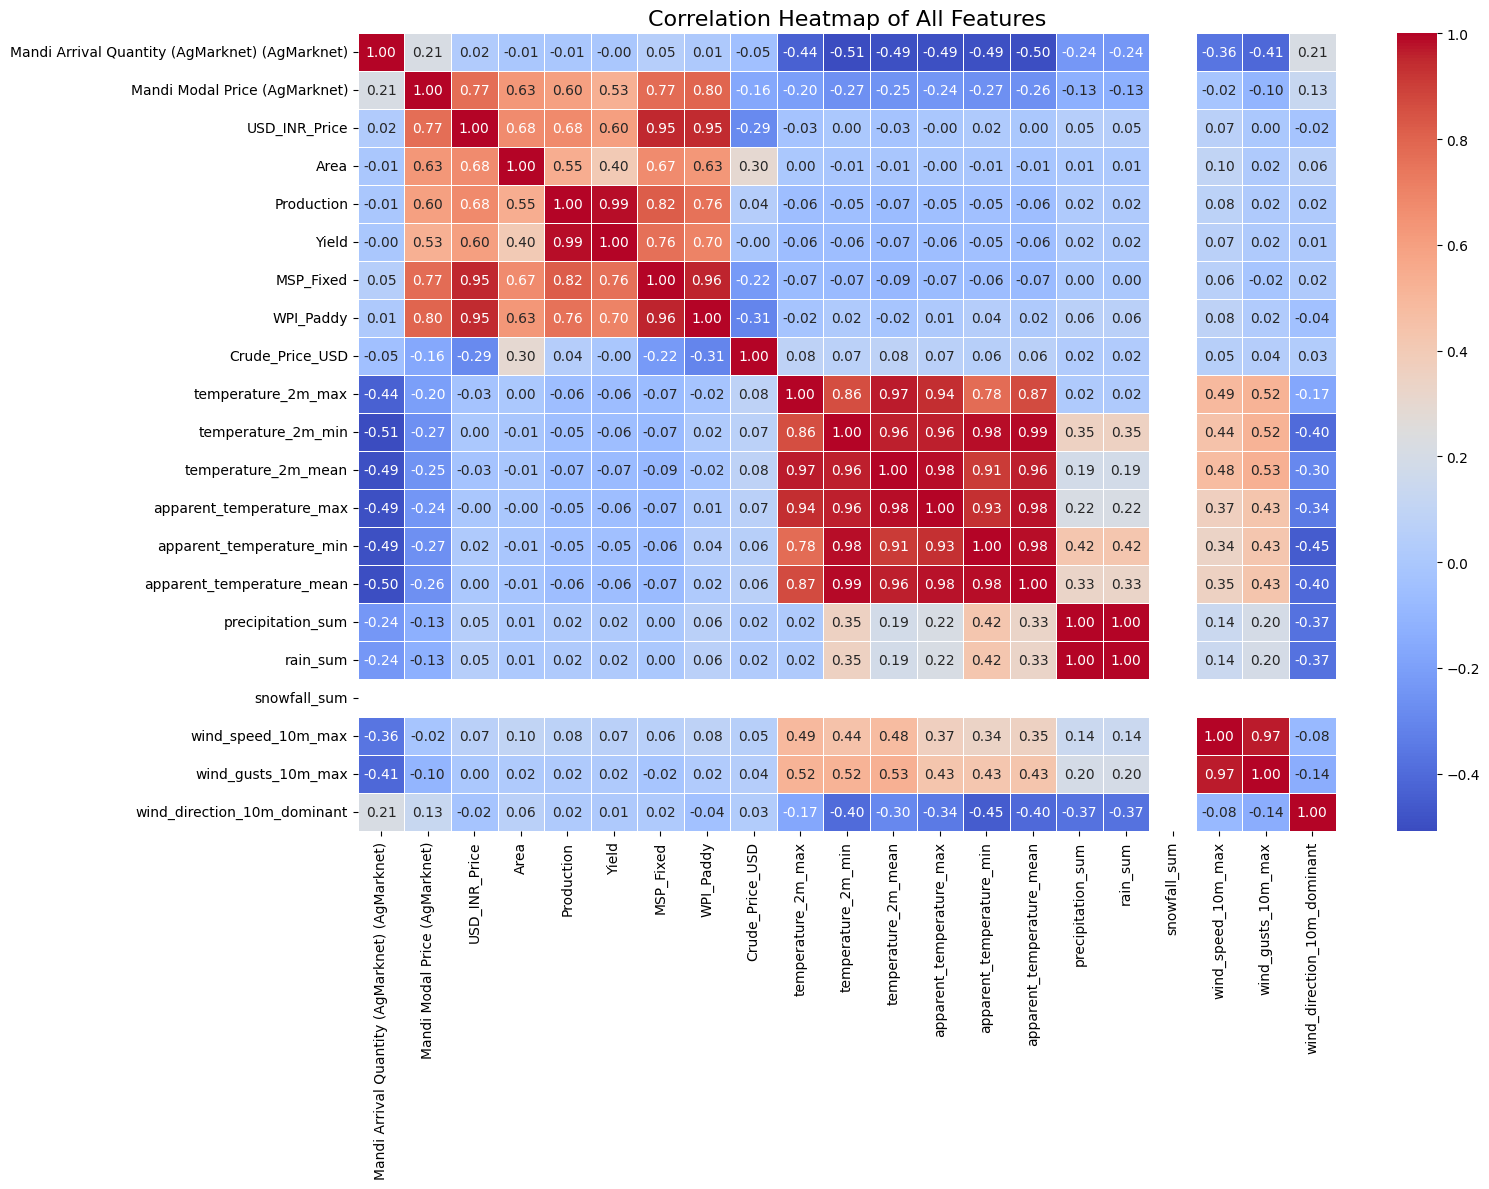

Heatmap saved → heatmap.png

Top 6 features influencing 'Mandi Modal Price (AgMarknet)':
  WPI_Paddy                                 r = 0.80
  MSP_Fixed                                 r = 0.77
  USD_INR_Price                             r = 0.77
  Area                                      r = 0.63
  Production                                r = 0.60
  Yield                                     r = 0.53


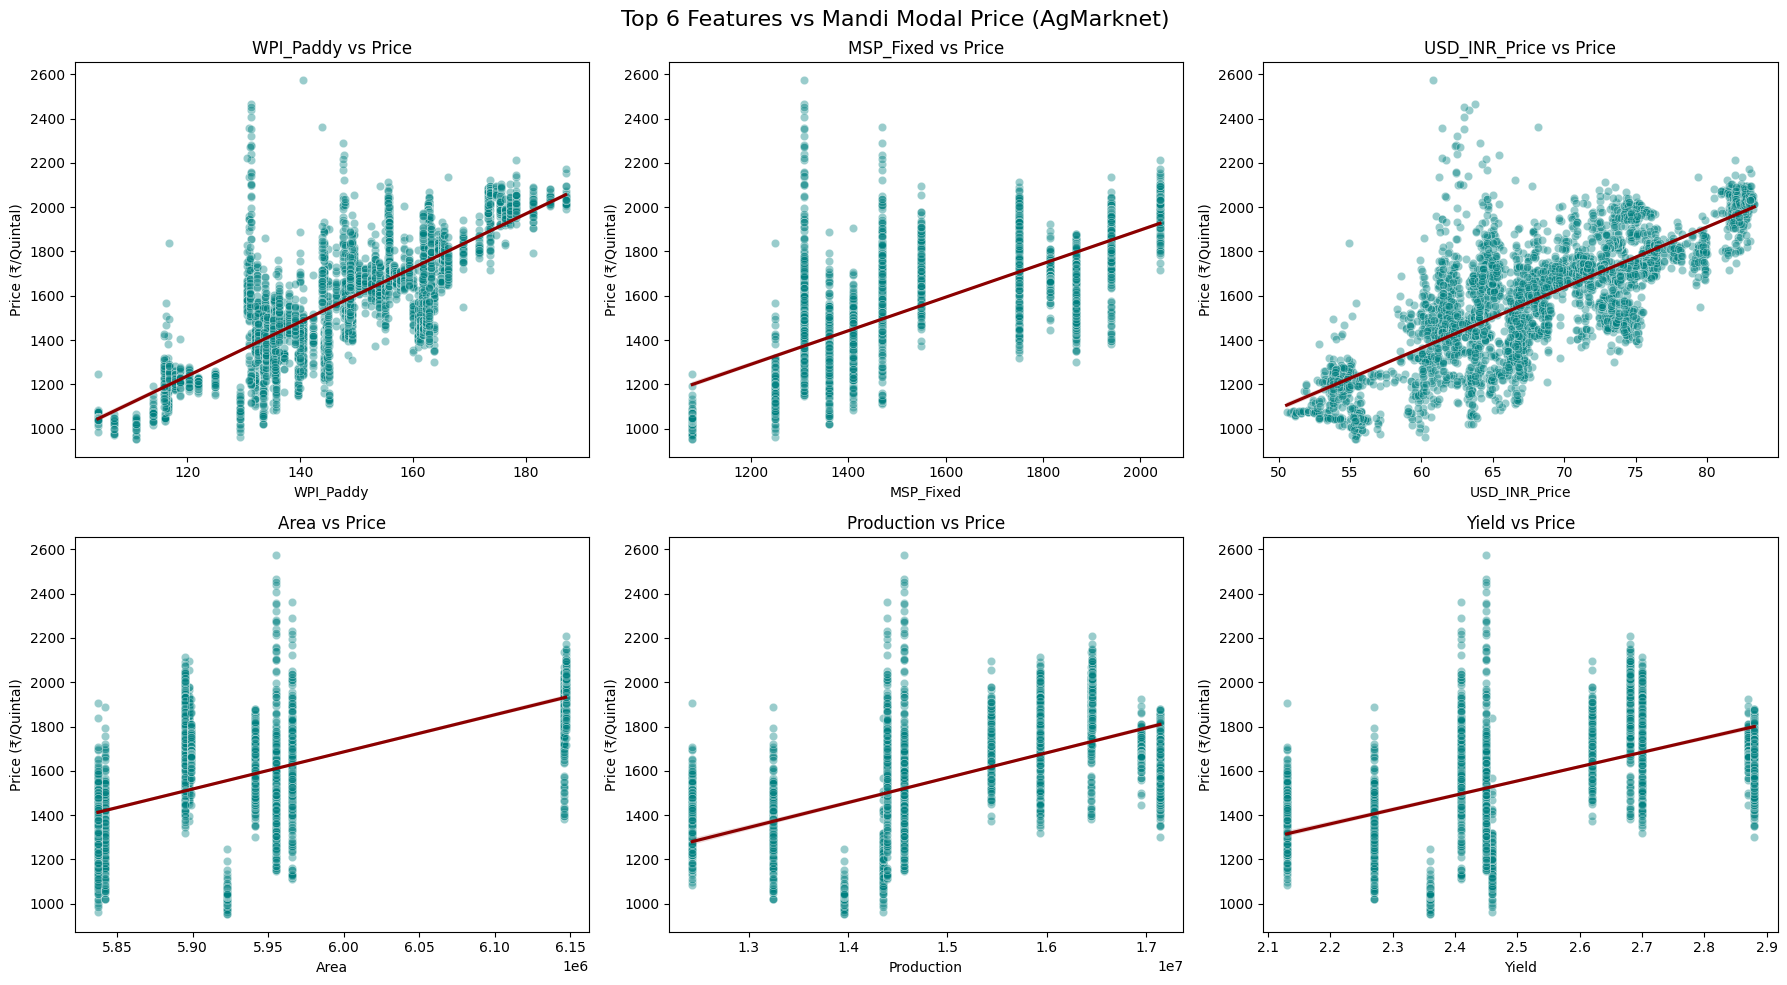

Scatter plots saved → scatter_top_features.png

Pipeline complete!


In [2]:
# =============================================================================
#  AGRICULTURAL PRICE MODELLING PIPELINE
#  Combines market prices, forex, crop yield, MSP, WPI, crude oil & weather
#  into a single ML-ready dataset for Uttar Pradesh Paddy.
# =============================================================================

import os
import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf


# =============================================================================
# SECTION 1: LOAD RAW DATA FILES
# =============================================================================

print("=" * 60)
print("SECTION 1: Loading raw data files...")
print("=" * 60)

# --- Market Prices (daily Mandi data from AgMarknet) ---
df_up_paddy = pd.read_csv('../Uttar-Pradesh,-Paddy,-(Jan-01,-2011-to-Apr-02,-2026).csv')

# --- USD/INR Exchange Rate (historical daily) ---
df_usd_inr = pd.read_csv('../USD_INR Historical Data.csv')

# --- Wholesale Price Index for Paddy ---
df_wpi_paddy = pd.read_excel('../WPI_Paddy_1.ods', engine='odf', header=0).iloc[:, 0:3]

# --- Minimum Support Price (government-set floor price per crop year) ---
df_msp = pd.read_excel('../MSP.ods', engine='odf').iloc[:, 0:3]

# --- Area, Production & Yield by State/Year (APY dataset) ---
df_apy = pd.read_excel('../APY.ods', engine='odf')

print("All raw files loaded successfully.\n")


# =============================================================================
# SECTION 2: BUILD THE DAILY MANDI PRICE BASE TABLE
#             Merge market prices with USD/INR exchange rate
# =============================================================================

print("SECTION 2: Merging Mandi prices with USD/INR exchange rate...")

# Normalise date formats so both tables share the same dtype
df_up_paddy['Calendar'] = pd.to_datetime(df_up_paddy['Calendar'])
df_usd_inr['Date'] = pd.to_datetime(df_usd_inr['Date'], format='%d-%m-%Y')

# Keep only the columns we need from the forex table
df_usd_subset = (
    df_usd_inr[['Date', 'Price']]
    .rename(columns={'Price': 'USD_INR_Price'})
)

# Left-join so every paddy row is preserved even if a forex date is missing
df_final = pd.merge(
    df_up_paddy,
    df_usd_subset,
    left_on='Calendar',
    right_on='Date',
    how='left'
).drop(columns=['Date'])  # redundant after merge

# Forward-fill weekends / holidays, then back-fill the very first row if needed
df_final['USD_INR_Price'] = df_final['USD_INR_Price'].ffill().bfill()

print("USD/INR merge complete.\n")


# =============================================================================
# SECTION 3: COMPUTE STATE-LEVEL CROP YIELD FROM APY DATA
# =============================================================================

print("SECTION 3: Computing annual crop yield for Uttar Pradesh...")

# Forward-fill merged State / District labels (common in government Excel exports)
df_apy['State']    = df_apy['State'].ffill()
df_apy['District'] = df_apy['District'].ffill()

# Aggregate to state-year level (sum area & production across all districts)
df_up_aggregated = (
    df_apy
    .groupby(['State', 'Year'])[['Area (Hectare)', 'Production (Tonnes)']]
    .sum()
    .reset_index()
    .rename(columns={'Area (Hectare)': 'Area', 'Production (Tonnes)': 'Production'})
)

# Yield = Production per unit area (tonnes / hectare), rounded to 2 dp
df_up_aggregated['Yield'] = (
    df_up_aggregated['Production'] / df_up_aggregated['Area']
).round(2)

print("Yield computation complete.\n")


# =============================================================================
# SECTION 4: ASSIGN KHARIF CROP YEAR TO EACH DAILY RECORD
#             Then merge in Area, Production & Yield
# =============================================================================

print("SECTION 4: Mapping each date to its Kharif crop year...")

def get_crop_year(date):
    """
    Maps a calendar date to the corresponding Indian Kharif crop year.
    - Oct onwards  → current harvest  (e.g. Oct 2024 → "2024 - 2025")
    - Before Oct   → previous harvest (e.g. Mar 2025 → "2024 - 2025")
    """
    if date.month >= 10:
        return f"{date.year} - {date.year + 1}"
    return f"{date.year - 1} - {date.year}"

df_final['Crop_Year'] = df_final['Calendar'].apply(get_crop_year)

# Bring in yield metrics, matching on the crop year string
df_model_ready = pd.merge(
    df_final,
    df_up_aggregated[['Year', 'Area', 'Production', 'Yield']],
    left_on='Crop_Year',
    right_on='Year',
    how='left'
).drop(columns=['Year'])

print("Crop year & yield merge complete.\n")


# =============================================================================
# SECTION 5: MERGE MINIMUM SUPPORT PRICE (MSP)
# =============================================================================

print("SECTION 5: Merging MSP data...")

# Load & clean MSP
df_msp_clean = df_msp.copy()
df_msp_clean.columns = ['Raw_Year', 'MSP_Rec', 'MSP_Fixed']

# Drop placeholder rows (dashes, blanks)
df_msp_clean = df_msp_clean[df_msp_clean['MSP_Fixed'] != '-']
df_msp_clean['MSP_Fixed'] = pd.to_numeric(df_msp_clean['MSP_Fixed'], errors='coerce')

def format_msp_year(y):
    """
    Converts the government format "2024-25" → "2024 - 2025"
    so it aligns with the Crop_Year column already in the dataset.
    """
    if pd.isna(y):
        return y
    parts = str(y).strip().split('-')
    if len(parts) == 2:
        end_year = f"20{parts[1]}" if len(parts[1]) == 2 else parts[1]
        return f"{parts[0]} - {end_year}"
    return y

df_msp_clean['Crop_Year'] = df_msp_clean['Raw_Year'].apply(format_msp_year)

df_final_model = pd.merge(
    df_model_ready,
    df_msp_clean[['Crop_Year', 'MSP_Fixed']],
    on='Crop_Year',
    how='left'
)

print("MSP merge complete.\n")


# =============================================================================
# SECTION 6: MERGE WHOLESALE PRICE INDEX (WPI) FOR PADDY
# =============================================================================

print("SECTION 6: Merging WPI (Wholesale Price Index)...")

# Map abbreviated month names to zero-padded month numbers
month_map = {
    'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04',
    'May': '05', 'Jun': '06', 'Jul': '07', 'Aug': '08',
    'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'
}

# Drop placeholder rows and cast to numeric
df_wpi_paddy = df_wpi_paddy[df_wpi_paddy.iloc[:, 2] != '-'].copy()
df_wpi_paddy.columns = ['Year', 'Month', 'WPI_Paddy']
df_wpi_paddy['WPI_Paddy'] = pd.to_numeric(df_wpi_paddy['WPI_Paddy'], errors='coerce')

# Build a "YYYY-MM" key for monthly matching
df_wpi_paddy['Month_Num'] = df_wpi_paddy['Month'].map(month_map)
df_wpi_paddy['Year_Month'] = df_wpi_paddy['Year'].astype(str) + '-' + df_wpi_paddy['Month_Num']
df_wpi_clean = df_wpi_paddy[['Year_Month', 'WPI_Paddy']]

# Create the same key in the main dataset
df_final_model['Year_Month'] = df_final_model['Calendar'].dt.strftime('%Y-%m')

df_final_model = pd.merge(
    df_final_model,
    df_wpi_clean,
    on='Year_Month',
    how='left'
).drop(columns=['Year_Month'])

# Remove rows before April 2012 where WPI data is unavailable
df_final_model = df_final_model.dropna(subset=['WPI_Paddy'])

print("WPI merge complete.\n")


# =============================================================================
# SECTION 7: FETCH & MERGE BRENT CRUDE OIL PRICE (via yfinance)
# =============================================================================

print("SECTION 7: Fetching Brent Crude Oil prices from Yahoo Finance...")

crude_data = yf.download('BZ=F', start='2012-04-01', end='2026-04-02')
crude_data = crude_data.reset_index()

crude_clean = crude_data[['Date', 'Close']].copy()
crude_clean.columns = ['Calendar', 'Crude_Price_USD']

# Strip timezone info so both sides match cleanly on merge
crude_clean['Calendar'] = pd.to_datetime(crude_clean['Calendar']).dt.tz_localize(None)
df_final_model['Calendar'] = pd.to_datetime(df_final_model['Calendar']).dt.tz_localize(None)

df_final_model = pd.merge(
    df_final_model,
    crude_clean,
    on='Calendar',
    how='left'
)

# Crude doesn't trade on weekends — carry Friday's price forward into Sat/Sun
df_final_model['Crude_Price_USD'] = df_final_model['Crude_Price_USD'].ffill().bfill()

print("Crude Oil merge complete.\n")

# --- Save intermediate master dataset (without weather) ---
df_final_model.to_csv('Master_Agri_Dataset.csv', index=False)
print("Saved intermediate file → Master_Agri_Dataset.csv\n")


# =============================================================================
# SECTION 8: LOAD, AVERAGE & MERGE DISTRICT-LEVEL WEATHER DATA
# =============================================================================

print("SECTION 8: Processing district weather data...")

WEATHER_DIR = '../weather_data/'

# Read every file in the weather directory and stack them
weather_files = glob.glob(os.path.join(WEATHER_DIR, '*'))
all_weather_data = []

for file in weather_files:
    try:
        df_w = pd.read_csv(file)
        all_weather_data.append(df_w)
    except Exception as e:
        print(f"  [Warning] Could not read {file}: {e}")

combined_weather_df = pd.concat(all_weather_data, ignore_index=True)

# Normalise the date column — drop the timezone / timestamp part
WEATHER_DATE_COL = 'date'
combined_weather_df[WEATHER_DATE_COL] = (
    pd.to_datetime(combined_weather_df[WEATHER_DATE_COL]).dt.date
)

# Average all numerical weather variables across all districts for each day
state_avg_weather_df = (
    combined_weather_df
    .groupby(WEATHER_DATE_COL)
    .mean()
    .reset_index()
)

# Normalise the master dataset date to plain date objects for an exact match
master_df = pd.read_csv('Master_Agri_Dataset.csv')
master_df['Calendar'] = pd.to_datetime(master_df['Calendar']).dt.date

# Left-join: keep every market-price row; attach weather where dates match
final_df = pd.merge(
    master_df,
    state_avg_weather_df,
    left_on='Calendar',
    right_on=WEATHER_DATE_COL,
    how='left'
).drop(columns=[WEATHER_DATE_COL])  # redundant after merge

# --- Save the final ML-ready dataset ---
OUTPUT_FILE = 'final_combined_dataset.csv'
final_df.to_csv(OUTPUT_FILE, index=False)
print(f"Final dataset saved → {OUTPUT_FILE}\n")


# =============================================================================
# SECTION 9: EXPLORATORY DATA ANALYSIS (EDA)
#             Correlation heatmap + scatter plots for top features
# =============================================================================

print("SECTION 9: Generating EDA plots...")

df = pd.read_csv('final_combined_dataset.csv')
TARGET_COL = 'Mandi Modal Price (AgMarknet)'

# Keep only numerical columns and drop any remaining NaNs
numeric_df = df.select_dtypes(include=['float64', 'int64']).dropna()

# ------------------------------------------------------------------
# Plot 1: Full Correlation Heatmap
# ------------------------------------------------------------------
plt.figure(figsize=(16, 12))

correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',    # blue = negative, red = positive
    linewidths=0.5
)

plt.title('Correlation Heatmap of All Features', fontsize=16)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()
print("Heatmap saved → heatmap.png")

# ------------------------------------------------------------------
# Plot 2: Scatter Plots — Top 6 Features vs Target Price
# ------------------------------------------------------------------
correlations_with_target = correlation_matrix[TARGET_COL].drop(TARGET_COL)
top_features = (
    correlations_with_target
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
)

print(f"\nTop 6 features influencing '{TARGET_COL}':")
for feat in top_features:
    print(f"  {feat:40s}  r = {correlations_with_target[feat]:.2f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Top 6 Features vs {TARGET_COL}', fontsize=16)
axes = axes.flatten()

for i, feature in enumerate(top_features):
    # Raw scatter
    sns.scatterplot(
        data=numeric_df, x=feature, y=TARGET_COL,
        ax=axes[i], alpha=0.4, color='teal'
    )
    # OLS trend line
    sns.regplot(
        data=numeric_df, x=feature, y=TARGET_COL,
        ax=axes[i], scatter=False, color='darkred'
    )
    axes[i].set_title(f'{feature} vs Price')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Price (₹/Quintal)')

plt.tight_layout()
plt.savefig('scatter_top_features.png', dpi=150)
plt.show()
print("Scatter plots saved → scatter_top_features.png\n")

print("=" * 60)
print("Pipeline complete!")
print("=" * 60)